# Interpolate Model Grid

Interpolate an atmospheric model grid to generate a synthetic spectrum with a given combination of free parameters within the grid coverage.

In [1]:
import seda
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, AutoMinorLocator, StrMethodFormatter, NullFormatter


    SEDA v0.8.6 package imported


## Model options

In [2]:
# import importlib
# importlib.reload(seda.utils)
# import seda

# Select the atmospheric models of interest
model = 'ATMO2020'

# Path to the directory or directories containing the model spectra
# (update it to your own path)
model_dir = ['/home/gsuarez/TRABAJO/MODELS/atmosphere_models/ATMO2020/atmosphere_models/CEQ_spectra',
             '/home/gsuarez/TRABAJO/MODELS/atmosphere_models/ATMO2020/atmosphere_models/NEQ_weak_spectra',
             '/home/gsuarez/TRABAJO/MODELS/atmosphere_models/ATMO2020/atmosphere_models/NEQ_strong_spectra'
            ]

## Desired model spectrum

Parameter combination for the desired model spectrum.

As an example, for easier verification below, let's consider one free parameter varying between grid nodes while keeping the remaining parameters fixed at grid node values.

Grid node points are:

In [3]:
seda.models.Models(model).params_unique

{'Teff': array([ 200.,  250.,  300.,  350.,  400.,  450.,  500.,  550.,  600.,
         700.,  800.,  900., 1000., 1100., 1200., 1300., 1400., 1500.,
        1600., 1700., 1800., 1900., 2000., 2100., 2200., 2300., 2400.,
        2500., 2600., 2700., 2800., 2900., 3000.]),
 'logg': array([2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 'logKzz': array([0., 4., 6.])}

Set Teff and logg to grid values, and logKzz to a value between grid nodes.

In [4]:
params = {'Teff': 1000, 'logg': 4.5, 'logKzz': 2.5}

## Generate the spectrum

In [5]:
out_generate_model_spectrum = seda.utils.generate_model_spectrum(params=params, 
                                                                 model=model, 
                                                                 model_dir=model_dir)


      510 model spectra
         user-constrained parameters:
         model-constrained parameters:
            Teff range = [200.0, 3000.0]
            logg range = [2.5, 5.5]
            logKzz range = [0.0, 6.0]

      2 model spectra
         user-constrained parameters:
             Teff range = [1000. 1000.]
             logg range = [4.5 4.5]
             logKzz range = [0. 4.]
         model-constrained parameters:


Reading model grid:   0%|          | 0/2 [00:00<?, ?it/s]

      elapsed time: 0.0 s


Extract spectrum from the outpur dictionary:

In [6]:
wl_spec = out_generate_model_spectrum['wavelength'] # in um
flux_spec = out_generate_model_spectrum['flux'] # in erg/s/cm2/A

## Validation plot

Verify that the interpolated spectrum lies between the two consecutive model spectra. 

Read reference spectra.

In [7]:
# First reference spectrum
spectrum_name_full = '/home/gsuarez/TRABAJO/MODELS/atmosphere_models/ATMO2020/atmosphere_models/CEQ_spectra/spec_T1000_lg4.5_CEQ.txt'
out_read_model_spectrum = seda.models.read_model_spectrum(spectrum_name_full=spectrum_name_full, model=model)
wl_ref1 = out_read_model_spectrum['wl_model'] # in um
flux_ref1 = out_read_model_spectrum['flux_model'] # in erg/s/cm2/A

# Second reference spectrum
spectrum_name_full = '/home/gsuarez/TRABAJO/MODELS/atmosphere_models/ATMO2020/atmosphere_models/NEQ_weak_spectra/spec_T1000_lg4.5_NEQ_weak.txt'
out_read_model_spectrum = seda.models.read_model_spectrum(spectrum_name_full=spectrum_name_full, model=model)
wl_ref2 = out_read_model_spectrum['wl_model'] # in um
flux_ref2 = out_read_model_spectrum['flux_model'] # in erg/s/cm2/A

Plot

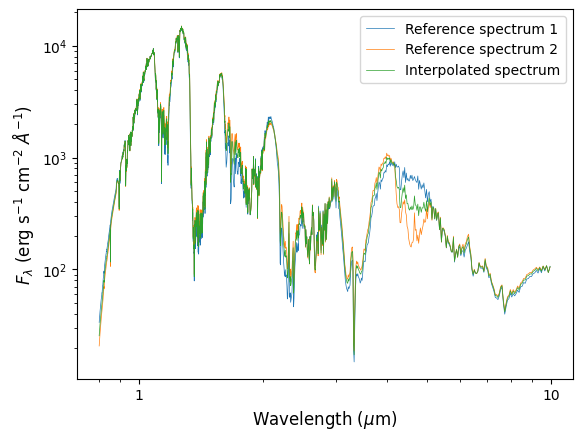

In [8]:
fig, ax = plt.subplots()

xmin, xmax = 0.8, 10

# reference spectra
mask = (wl_ref1>xmin) & (wl_ref1<xmax)
plt.plot(wl_ref1[mask], flux_ref1[mask], linewidth=0.5, label='Reference spectrum 1')
mask = (wl_ref2>xmin) & (wl_ref2<xmax)
plt.plot(wl_ref2[mask], flux_ref2[mask], linewidth=0.5, label='Reference spectrum 2')

# interpolated spectrum
mask = (wl_spec>xmin) & (wl_spec<xmax)
plt.plot(wl_spec[mask], flux_spec[mask], linewidth=0.5, label='Interpolated spectrum')

plt.legend()

plt.xscale('log')
plt.yscale('log')

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

plt.xlabel(r'Wavelength ($\mu$m)', size=12)
plt.ylabel(r'$F_\lambda\ ($erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', size=12)

plt.show()

## Generate several model spectra

The slowest part of the process to interpolate the a model grid is to read the model grid. So, we can read the grid or a grid subset separately to then be used for interpolations.

Optional: Define parameter ranges to select a subset of the grid that covers the desired spectrum. If no range is specified for a parameter, the full grid range will be used.

### Read grid

In [9]:
params_ranges = {
    'Teff': [500, 1000], # Teff range
    'logg': [4.0, 5.0], # logg range
    'Z': [0, 4] # logg range
}

# Read grid
grid = seda.utils.read_grid(model=model, model_dir=model_dir, params_ranges=params_ranges)


      63 model spectra
         user-constrained parameters:
             Teff range = [500, 1000]
             logg range = [4.0, 5.0]
             Z range = [0, 4]
         model-constrained parameters:
            logKzz range = [0.0, 6.0]


Reading model grid:   0%|          | 0/63 [00:00<?, ?it/s]

      elapsed time: 0.0 s


### Generate spectra

Use the loaded grid to interpolate model spectra with its coverage.

Synthetic spectra for a fixed logg and logKzz but changing Teff in steps of 10 K.

In [10]:
Teff = np.arange(600, 710, 10)

wl = []
flux = []
for T in Teff:
    params = {'Teff': T, 'logg': 4.5, 'logKzz': 5.5}
    out = seda.utils.generate_model_spectrum(params=params, model=model, grid=grid)
    wl.append(out['wavelength'])
    flux.append(out['flux'])

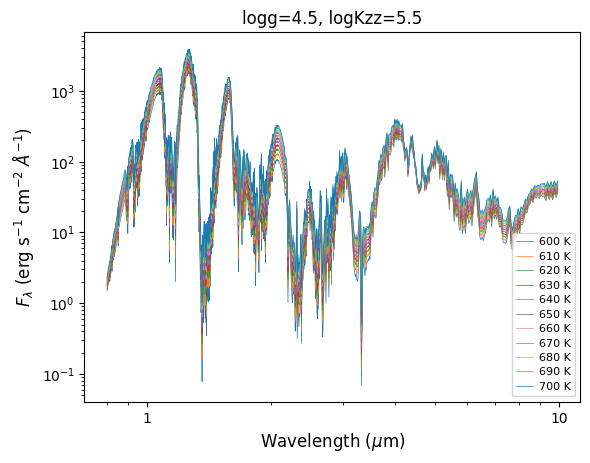

In [12]:
fig, ax = plt.subplots()

xmin, xmax = 0.8, 10

for i, (w,f) in enumerate(zip(wl,flux)):
    mask = (w>xmin) & (w<xmax)
    plt.plot(w[mask], f[mask], linewidth=0.5, label=f'{Teff[i]} K')

plt.legend(fontsize=8, handlelength=1.5, handletextpad=0.5, labelspacing=0.4)

plt.xscale('log')
plt.yscale('log')

ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))

plt.title(f'logg={params["logg"]}, logKzz={params["logKzz"]}')
plt.xlabel(r'Wavelength ($\mu$m)', size=12)
plt.ylabel(r'$F_\lambda\ ($erg s$^{-1}$ cm$^{-2}$ $\AA^{-1}$)', size=12)

plt.show()